In [2]:
from Bio.PDB import PDBList, PDBParser
import os
# скачиваем структуру грамицидина А
pdbl=PDBList()
pdb_id='1MAG'

# сохраняем в data/structures/
os.makedirs('../data/structures', exist_ok=True)
pdbl.retrieve_pdb_file(pdb_id, file_format='pdb',pdir='../data/structures/')

Structure exists: '../data/structures/pdb1mag.ent' 


'../data/structures/pdb1mag.ent'

In [3]:
parser = PDBParser(QUIET=True)
structure = parser.get_structure('gramicidin_A', "../data/structures/pdb1mag.ent")

print(f'Обьект структуры:{structure}')
print(f"Количество моделей: {len(structure)}")

# Разбираем структуру первой модели
model = structure[0]
for chain in model:
    print(f"Цепь: {chain.id}")
    residues = list(chain.get_residues())
    print(f"  Количество остатков: {len(residues)}")
    print(f"  Первый остаток: {residues[0].resname}")
    print(f"  Последний остаток: {residues[-1].resname}")

Обьект структуры:<Structure id=gramicidin_A>
Количество моделей: 1
Цепь: A
  Количество остатков: 16
  Первый остаток: FVA
  Последний остаток: ETA
Цепь: B
  Количество остатков: 16
  Первый остаток: FVA
  Последний остаток: ETA


In [4]:
# найдем длину канала 
import numpy as np

# найдем координаты всех CA - атомов
ca_atoms = []
for chain in model:
    for residue in chain:
        # проверяем наличие CA атома
        if 'CA' in residue:
            ca_atoms.append(residue['CA'].get_vector().get_array())
ca_coords = np.array(ca_atoms)

# найдем длину по z
z_coords = ca_coords[:,2]
z_min = z_coords.min()
z_max = z_coords.max()
channel_length = z_max - z_min
print(f"Найдено CA-атомов: {len(ca_atoms)}")
print(f"Нижняя граница (Z_min): {z_min:.2f} Å")
print(f"Верхняя граница (Z_max): {z_max:.2f} Å")
print(f"Длина скелета канала: {channel_length:.2f} Å")
print(f"Толщина гидрофобной части липидной мембраны обычно ~26-30 Å.")

Найдено CA-атомов: 32
Нижняя граница (Z_min): -15.67 Å
Верхняя граница (Z_max): 8.83 Å
Длина скелета канала: 24.51 Å
Толщина гидрофобной части липидной мембраны обычно ~26-30 Å.


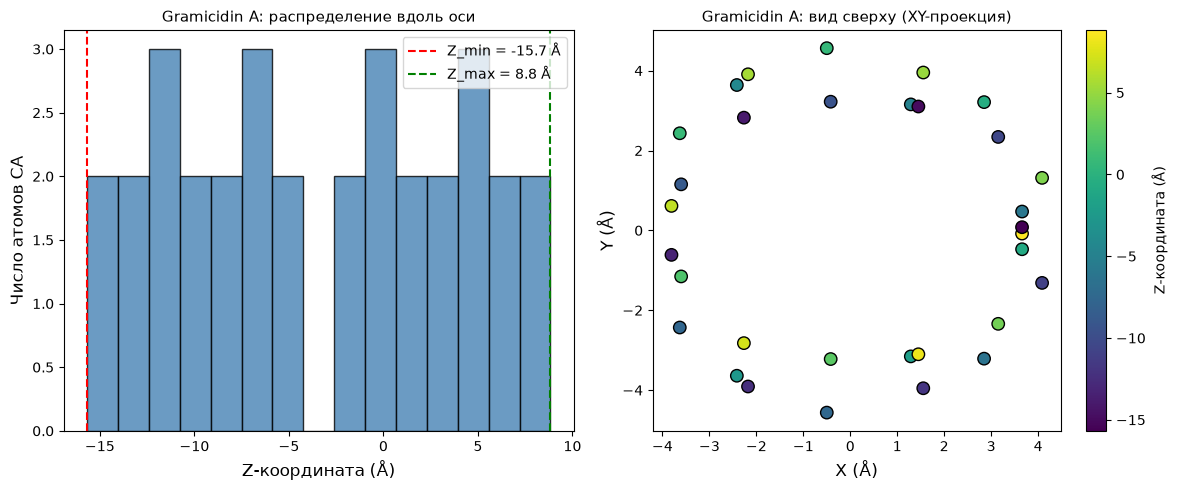

График успешно сохранен в папку results/


In [5]:
# построим визуализацию распределения атомов вдоль оси z и вид сверху на пору
import matplotlib.pyplot as plt
import os
os.makedirs("../results", exist_ok=True)
# Настраиваем размер фигуры (2 графика рядом)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# --- График 1: Гистограмма распределения по Z ---
ax1.hist(z_coords, bins=15, color='steelblue', edgecolor='black', alpha=0.8)
ax1.set_xlabel('Z-координата (Å)', fontsize=12)
ax1.set_ylabel('Число атомов CA', fontsize=12)
ax1.set_title('Gramicidin A: распределение вдоль оси', fontsize=11)
ax1.axvline(z_min, color='red', linestyle='--', label=f'Z_min = {z_min:.1f} Å')
ax1.axvline(z_max, color='green', linestyle='--', label=f'Z_max = {z_max:.1f} Å')
ax1.legend()
# --- График 2: XY-проекция ---
xy_coords = ca_coords[:, :2]
# Рисуем точки, цвет зависит от глубины (Z)
scatter = ax2.scatter(xy_coords[:, 0], xy_coords[:, 1], 
                      c=z_coords, cmap='viridis', s=80, edgecolor='black')
ax2.set_xlabel('X (Å)', fontsize=12)
ax2.set_ylabel('Y (Å)', fontsize=12)
ax2.set_title('Gramicidin A: вид сверху (XY-проекция)', fontsize=11)
# Добавляем цветовую карту
plt.colorbar(scatter, ax=ax2, label='Z-координата (Å)')

# Сохраняем и показываем
plt.tight_layout()
plt.savefig('../results/gramicidin_A_structure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("График успешно сохранен в папку results/")

In [7]:
# собираем тяжелые атомы
from Bio.PDB import PDBParser
import numpy as np

parser = PDBParser(QUIET=True)
structure = parser.get_structure(
    "gA",
    "../data/structures/pdb1mag.ent"
)

model = structure[0]

coords = []

for chain in model:
    for residue in chain:
        for atom in residue:
            # исключаем водороды
            if atom.element != "H":
                coords.append(atom.get_vector().get_array())

coords = np.array(coords)
z_values = coords[:, 2]

print("Количество тяжелых атомов:", len(coords))

Количество тяжелых атомов: 272


In [11]:
# считаем минимальный радиус канала, используем аналог HOLE метода
from Bio.PDB import PDBParser
import numpy as np

parser = PDBParser(QUIET=True)
structure = parser.get_structure(
    "gA",
    "../data/structures/pdb1mag.ent"
)

model = structure[0]

coords = []
vdw = []

# радиусы ван-дер-вальса для основных атомов
vdw_dict = {
    "C": 1.7,
    "N": 1.55,
    "O": 1.52,
    "S": 1.8
}

for chain in model:
    for residue in chain:
        for atom in residue:
            element = atom.element.strip()
            if element != "H":
                coords.append(atom.get_vector().get_array())
                vdw.append(vdw_dict.get(element, 1.7))

coords = np.array(coords)
vdw = np.array(vdw)

z_values = coords[:, 2]

print("Heavy atoms:", len(coords))

Heavy atoms: 272


In [17]:
# Находит максимальный радиус сферы в срезе.
def max_inscribed_radius(slice_points, slice_vdw, axis_xy, 
                         search_radius=5.0, grid_size=40):
    xy = slice_points[:, :2]
    
    x0, y0 = axis_xy
    
    xs = np.linspace(x0 - search_radius, x0 + search_radius, grid_size)
    ys = np.linspace(y0 - search_radius, y0 + search_radius, grid_size)
    
    max_radius = -np.inf
    
    for x in xs:
        for y in ys:
            dists = np.sqrt((xy[:,0]-x)**2 + (xy[:,1]-y)**2)
            effective = dists - slice_vdw
            r = effective.min()
            if r > max_radius:
                max_radius = r
    
    return max_radius

In [18]:
#расчитаем радиус
axis_xy = coords[:, :2].mean(axis=0)

slice_centers = []
slice_radii = []

for i in range(len(z_bins)-1):
    z_low = z_bins[i]
    z_high = z_bins[i+1]
    
    mask = (z_values >= z_low) & (z_values < z_high)
    
    slice_points = coords[mask]
    slice_vdw = vdw[mask]
    
    if len(slice_points) > 20:
        r = max_inscribed_radius(slice_points, slice_vdw, axis_xy,
                                 search_radius=4.0,
                                 grid_size=35)
        slice_centers.append((z_low + z_high)/2)
        slice_radii.append(r)

slice_radii = np.array(slice_radii)

print("Минимальный радиус поры:", slice_radii.min(), "Å")

Минимальный радиус поры: 1.5951654936943138 Å


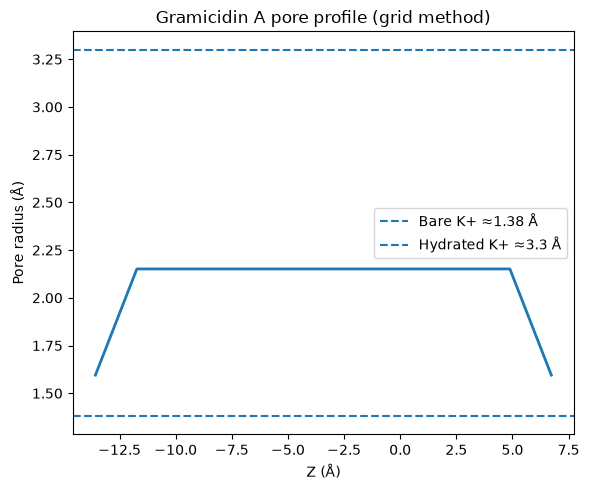

In [19]:
# визуализируем профиль
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.plot(slice_centers, slice_radii, linewidth=2)

plt.axhline(1.38, linestyle="--", label="Bare K+ ≈1.38 Å")
plt.axhline(3.3, linestyle="--", label="Hydrated K+ ≈3.3 Å")

plt.xlabel("Z (Å)")
plt.ylabel("Pore radius (Å)")
plt.legend()
plt.title("Gramicidin A pore profile (grid method)")
plt.tight_layout()
plt.savefig("../results/gramicidin_pore_profile_grid.png", dpi=150)
plt.show()

In [23]:
import numpy as np

# параметры
z = 1               # заряд K+
r = 1.38            # радиус голого K+ (Å)
epsilon_water = 78
epsilon_channel = 5

# формула Борна
def born_energy(z, r, epsilon):
    return -166 * z**2 / r * (1 - 1/epsilon)  # кДж/моль

G_water = born_energy(z, r, epsilon_water)
G_channel = born_energy(z, r, epsilon_channel)

delta_delta_G = G_channel - G_water

print(f"Born energy in water: {G_water:.1f} kJ/mol")
print(f"Born energy in channel: {G_channel:.1f} kJ/mol")
print(f"Estimated transfer penalty: {delta_delta_G:.1f} kJ/mol")

Born energy in water: -118.7 kJ/mol
Born energy in channel: -96.2 kJ/mol
Estimated transfer penalty: 22.5 kJ/mol


In [24]:
# посчитаем вероятность прохождения
import numpy as np

R = 8.314e-3   # кДж/(моль·K)
T = 298

RT = R * T

deltaG = delta_delta_G  # из расчёта Борна

probability = np.exp(-deltaG / RT)

print(f"RT ≈ {RT:.2f} kJ/mol")
print(f"ΔG / RT ≈ {deltaG/RT:.2f}")
print(f"Relative crossing probability ≈ {probability:.2e}")

RT ≈ 2.48 kJ/mol
ΔG / RT ≈ 9.09
Relative crossing probability ≈ 1.13e-04
